# Stock Price Prediction Using Hybrid LSTM
Sai Charan U-VU22csen0300283

/tmp/ipython-input-3374719425.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_prices = yf.download("AAPL", start="2020-01-01", end="2023-01-01")['Close'].values.reshape(-1, 1)
[*********************100%***********************]  1 of 1 completed


Epoch 0, Train Loss: 0.2822, Val Loss: 0.2980
Epoch 50, Train Loss: 0.2404, Val Loss: 0.1544
Epoch 100, Train Loss: 0.0455, Val Loss: 0.0166
Epoch 150, Train Loss: 0.0118, Val Loss: 0.0137
Epoch 200, Train Loss: 0.0101, Val Loss: 0.0133
Epoch 250, Train Loss: 0.0094, Val Loss: 0.0129
Epoch 300, Train Loss: 0.0087, Val Loss: 0.0124
Epoch 350, Train Loss: 0.0082, Val Loss: 0.0122
Epoch 400, Train Loss: 0.0078, Val Loss: 0.0120
Epoch 450, Train Loss: 0.0076, Val Loss: 0.0117


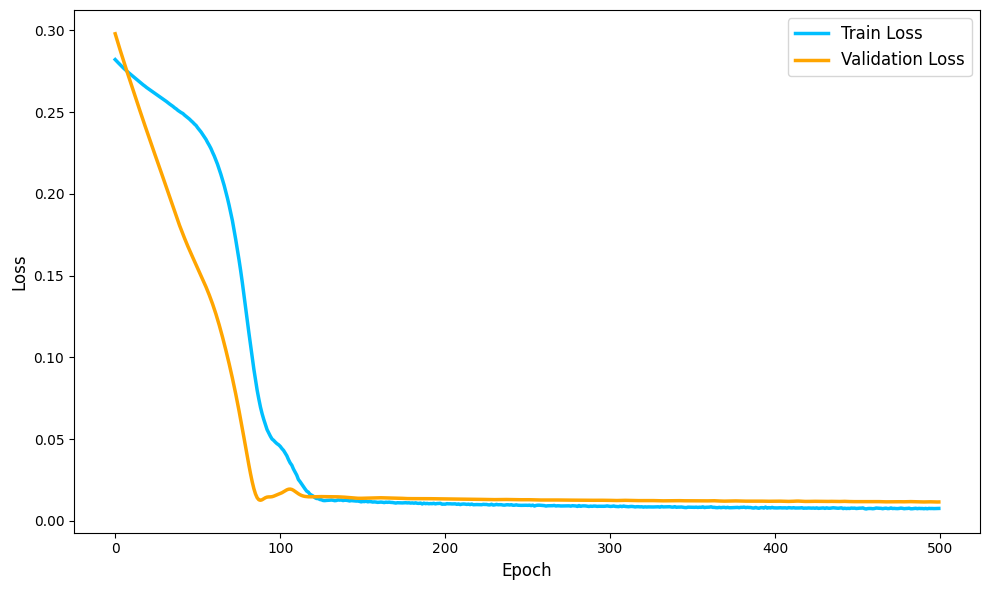


Evaluation Metrics:
Mean Absolute Error (MAE): 5.6464
Root Mean Squared Error (RMSE): 6.6421
R-squared (R² Score): 0.5984



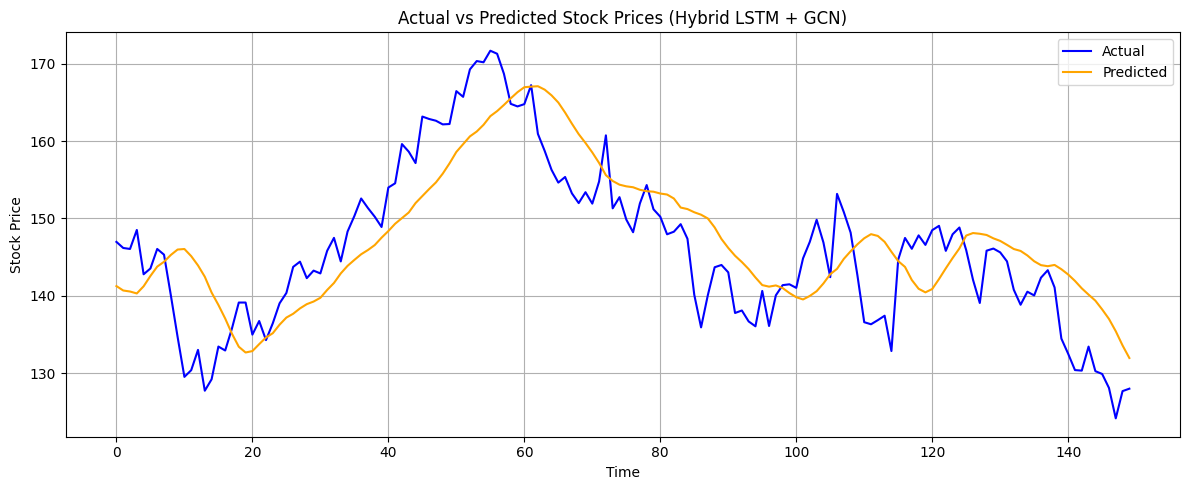

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import yfinance as yf


stock_prices = yf.download("AAPL", start="2020-01-01", end="2023-01-01")['Close'].values.reshape(-1, 1)
window_size = 10

# Normalize
scaler = MinMaxScaler(feature_range=(-1, 1))
stock_prices_scaled = scaler.fit_transform(stock_prices).flatten()

# Create Sequences
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

X, y = create_sequences(stock_prices_scaled, window_size)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

#  Convert to Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)  # shape: (batch, seq, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(-1)

#  Identity Matrix for GCN
adj_matrix = torch.eye(X.shape[0], dtype=torch.float32)

# Hybrid LSTM + GCN Model
class HybridLSTMGCN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(HybridLSTMGCN, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.gcn1 = nn.Linear(hidden_size, hidden_size)
        self.gcn2 = nn.Linear(hidden_size, 1)

    def forward(self, x, adj_matrix):
        lstm_out, _ = self.lstm(x)
        last_hidden = lstm_out[:, -1, :]  # last time step
        gcn_input = torch.matmul(adj_matrix[:last_hidden.shape[0], :last_hidden.shape[0]], last_hidden)
        x = torch.relu(self.gcn1(gcn_input))
        x = self.gcn2(x)
        return x

# Initialize Model
hidden_size = 128
num_layers = 3
model = HybridLSTMGCN(input_size=1, hidden_size=hidden_size, num_layers=num_layers)

# Loss and Optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

# Training & Validation
num_epochs = 500
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_train_tensor, adj_matrix[:X_train_tensor.shape[0], :X_train_tensor.shape[0]])
    loss = criterion(output, y_train_tensor)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_output = model(X_test_tensor, adj_matrix[:X_test_tensor.shape[0], :X_test_tensor.shape[0]])
        val_loss = criterion(val_output, y_test_tensor)

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

# Plot Loss Curve
plt.figure(figsize=(10, 6))
plt.plot(train_losses, color='deepskyblue', linewidth=2.5, label='Train Loss')
plt.plot(val_losses, color='orange', linewidth=2.5, label='Validation Loss')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.show()

# Evaluate Model
model.eval()
with torch.no_grad():
    preds = model(X_test_tensor, adj_matrix[:X_test_tensor.shape[0], :X_test_tensor.shape[0]])
    predictions = preds.squeeze().numpy()
    actuals = y_test_tensor.squeeze().numpy()

# Inverse Transform
predictions = scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()
actuals = scaler.inverse_transform(actuals.reshape(-1, 1)).flatten()

# Evaluation Metrics
mae = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mean_squared_error(actuals, predictions))
r2 = r2_score(actuals, predictions)

print("\nEvaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R² Score): {r2:.4f}\n")

# Plot Actual vs Predicted
plt.figure(figsize=(12, 5))
plt.plot(actuals, label='Actual', color='blue')
plt.plot(predictions, label='Predicted', color='orange')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.title('Actual vs Predicted Stock Prices (Hybrid LSTM + GCN)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

